<h1 style="color:#F0B4B4; font-size:32px;">Import modules</h1>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Loading datasets</h1>

In [3]:
directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers, 
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   

             Club points       mpp    mpp_date  SwimTime SwimTimeSeconds  \
0  MAINE-ET-LOIRE  930.0  02

In [31]:
print(df.columns)

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimTimeSeconds', 'Status', 'Speed',
       'swimmer', 'splits'],
      dtype='object')


In [33]:
print("Nombre de lignes :", df.shape[0])  # 762371

Nombre de lignes : 762371


In [35]:
nb_swimtime_vides = df['SwimTime'].isna().sum()
print("Nombre de SwimTime vides :", nb_swimtime_vides)
nb_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime présents :", nb_swimtime)

Nombre de SwimTime vides : 0
Nombre de SwimTime présents : 762371


In [36]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Age': 12,
  'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 12,
  'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [37]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [38]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.4837,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 2.6525,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 4.6802,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 7.0004,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


<h1 style="color:#F0B4B4; font-size:32px;">Histogram of swim times</h1>

Nombre de performances pour l'event 100 FR LCM: 49724


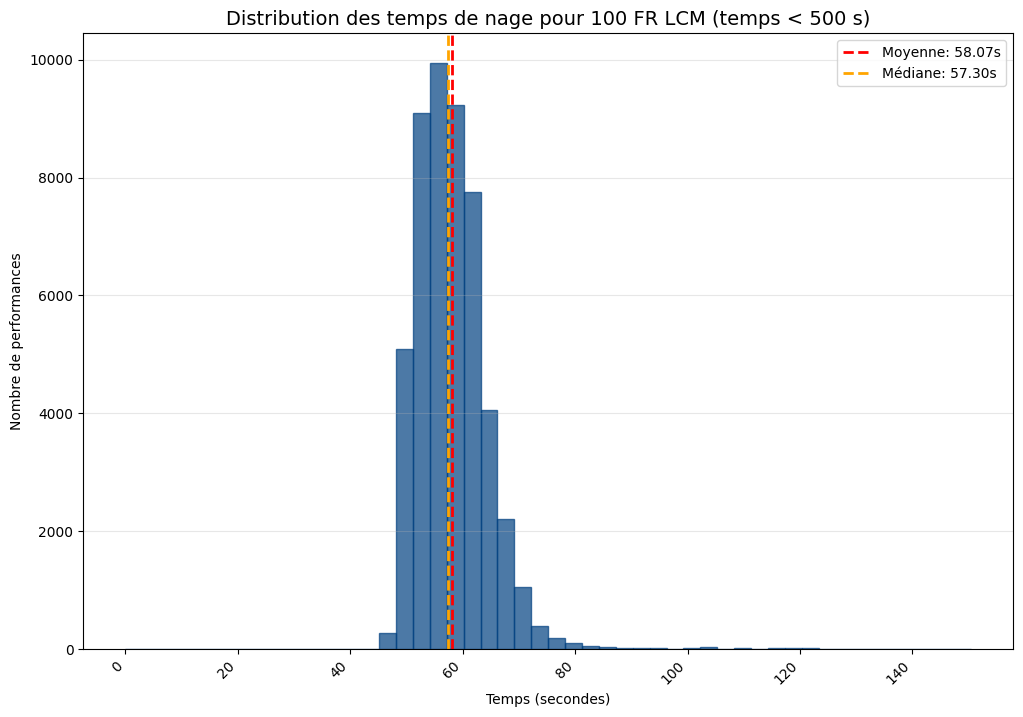

In [39]:
from matplotlib.ticker import MaxNLocator

nom_event = "100 FR LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
].dropna()

print(f"Nombre de performances pour l'event {nom_event}: {len(swim_times)}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2,
           label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2,
           label=f'Médiane: {median_time:.2f}s')

ax.set_title(f"Distribution des temps de nage pour {nom_event} (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Histogram with Kernel Density Estimate (KDE)</h1>

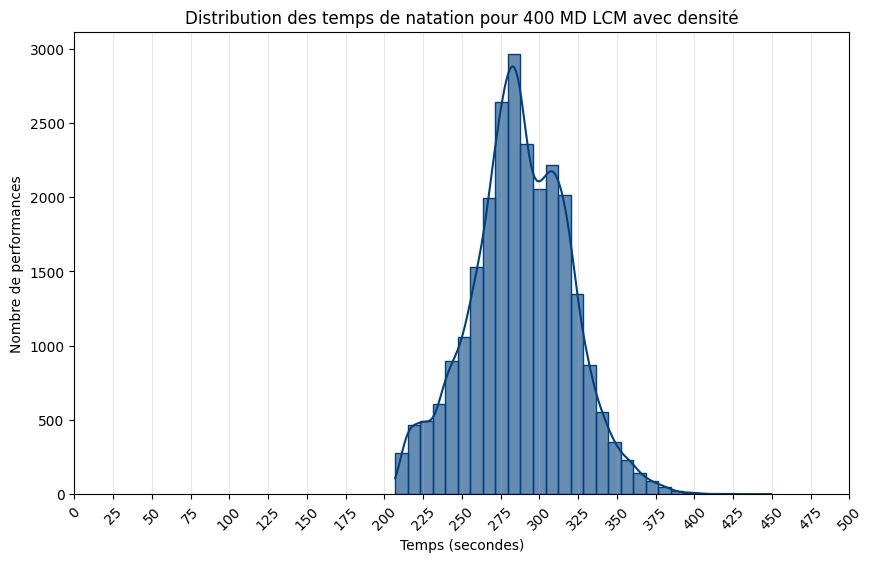

In [10]:
nom_event = "400 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"].notna()) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

plt.figure(figsize=(10,6))

sns.histplot(
    swim_times,
    bins=30,
    kde=True,
    color="#004080",
    edgecolor="#004080",
    alpha=0.6
)

plt.title(f"Distribution des temps de natation pour {nom_event} avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Cumulative Histogram</h1>

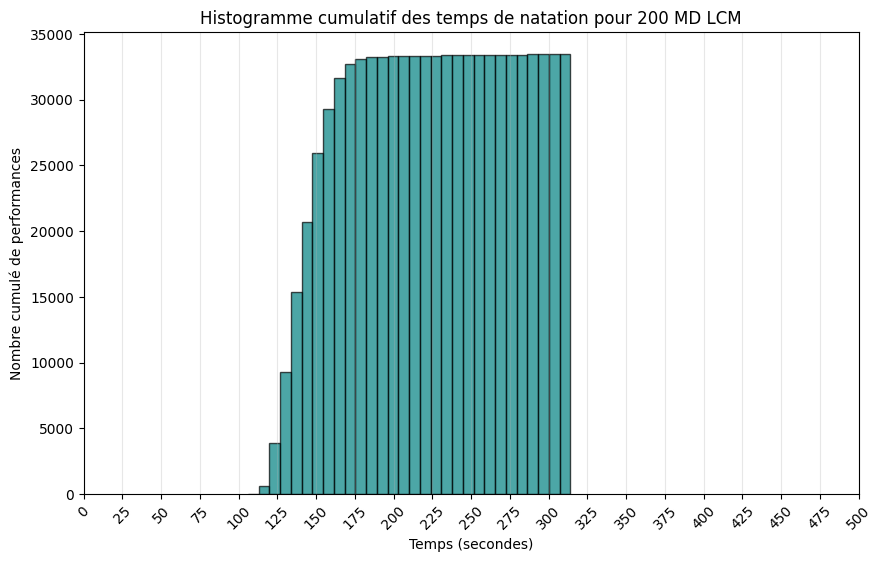

In [11]:
nom_event = "200 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

if len(swim_times) > 0:
    plt.figure(figsize=(10,6))

    plt.hist(
        swim_times,
        bins=30,
        cumulative=True,
        color="#008080",
        edgecolor="black",
        alpha=0.7
    )

    plt.title(f"Histogramme cumulatif des temps de natation pour {nom_event}")
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Nombre cumulé de performances")

    plt.xticks(np.arange(0, 501, 25), rotation=45)
    plt.grid(axis="x", alpha=0.3)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

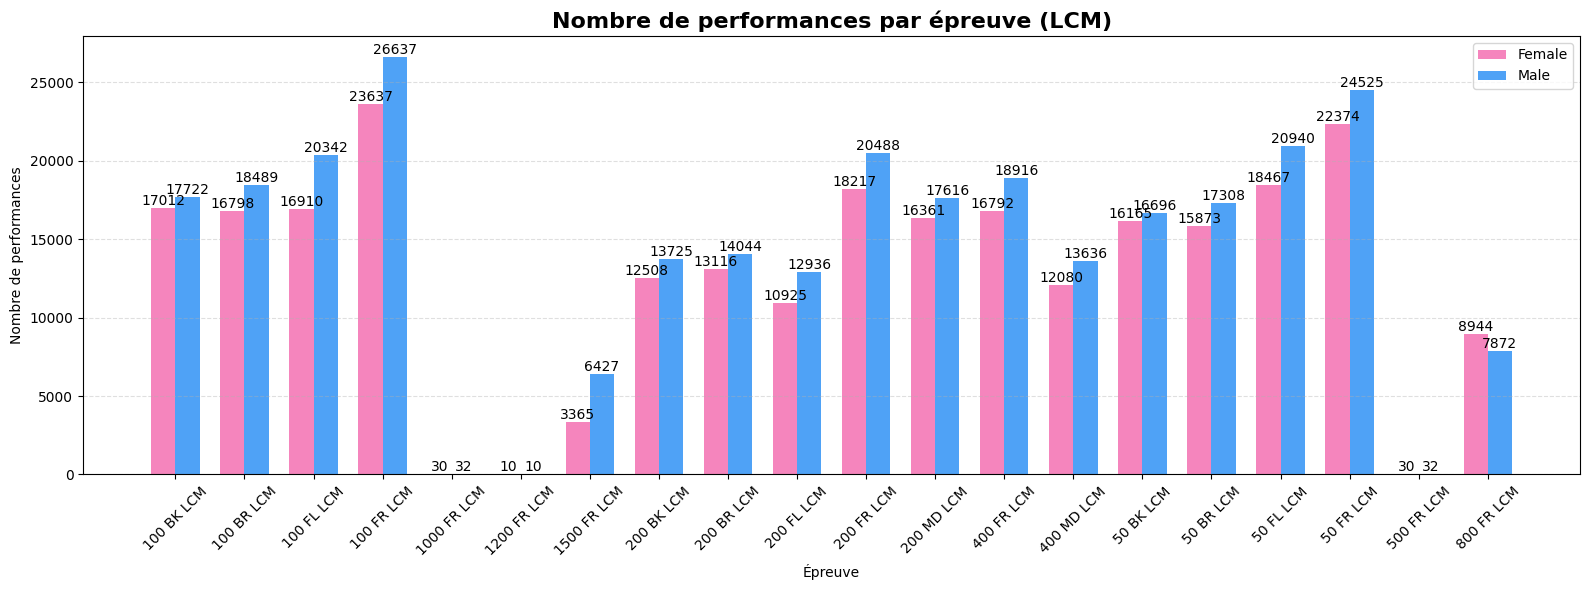

In [29]:
course_type = "LCM"

df["Gender"] = df["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 else None
)

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 else None
)

df_clean = df.dropna(subset=["Gender", "Event", "swimmer_name"])

df_clean = df_clean[df_clean["Event"].str.contains(course_type, na=False)]

df_counts = (
    df_clean
    .groupby(["Event", "Gender"])["swimmer_name"]
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

events = df_counts.index

female_counts = df_counts["F"] if "F" in df_counts else pd.Series(0, index=events)
male_counts = df_counts["M"] if "M" in df_counts else pd.Series(0, index=events)

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16, 6))

bars1 = plt.bar(
    x - width/2, female_counts, width,
    label="Female", color="#F585BD"
)

bars2 = plt.bar(
    x + width/2, male_counts, width,
    label="Male", color="#4FA2F6"
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title(
    f"Nombre de performances par épreuve ({course_type})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Épreuve")
plt.ylabel("Nombre de performances")

plt.xticks(x, events, rotation=45)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

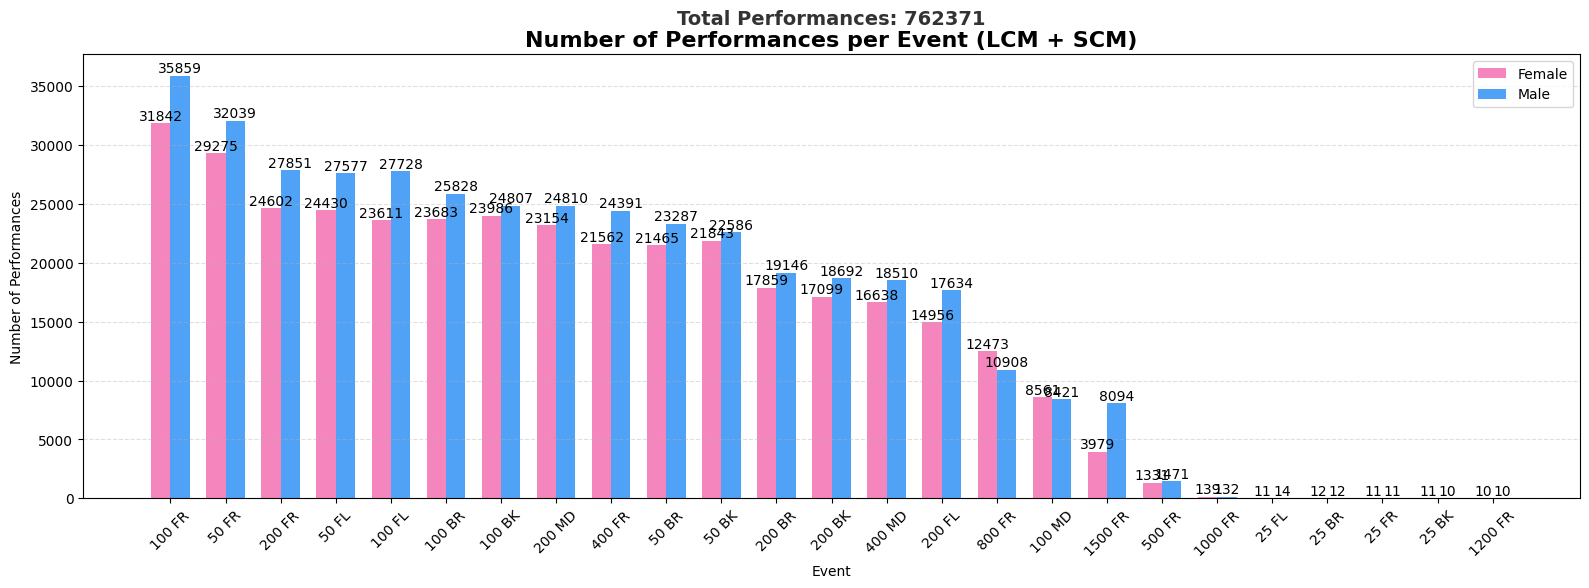

In [ ]:
df["Gender"] = df["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

df["Event_clean"] = df["Event"].str.replace(" LCM", "", regex=False)\
                               .str.replace(" SCM", "", regex=False)

df_clean = df.dropna(subset=["Gender", "Event_clean"])

df_counts = (
    df_clean
    .groupby(["Event_clean", "Gender"])
    .size()
    .unstack(fill_value=0)
)

df_counts["Total"] = df_counts.sum(axis=1)
df_counts = df_counts.sort_values("Total", ascending=False).drop(columns="Total")

total_performances = df_counts.sum().sum()

events = df_counts.index
female_counts = df_counts.get("F", [0]*len(events))
male_counts = df_counts.get("M", [0]*len(events))

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, female_counts, width, 
                label="Female", color="#F585BD")

bars2 = plt.bar(x + width/2, male_counts, width, 
                label="Male", color="#4FA2F6")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Number of Performances per Event (LCM + SCM)", fontsize=16, fontweight="bold")

plt.text(
    0.5, 1.08,
    f"Total Performances: {int(total_performances)}",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=14,
    fontweight='bold',
    color="#333333"
)

plt.xlabel("Event")
plt.ylabel("Number of Performances")
plt.xticks(x, events, rotation=45)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Countplot total number of performances by sex</h1>

Gender
M    399828
F    362543
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_3393/3315299978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=palette_colors)


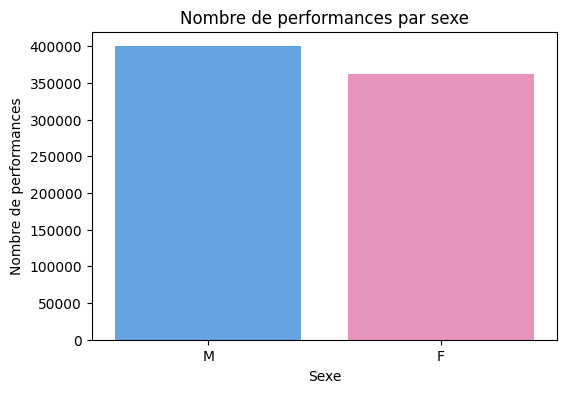

In [14]:
df["Gender"] = df["swimmer"].apply(lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None)

print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

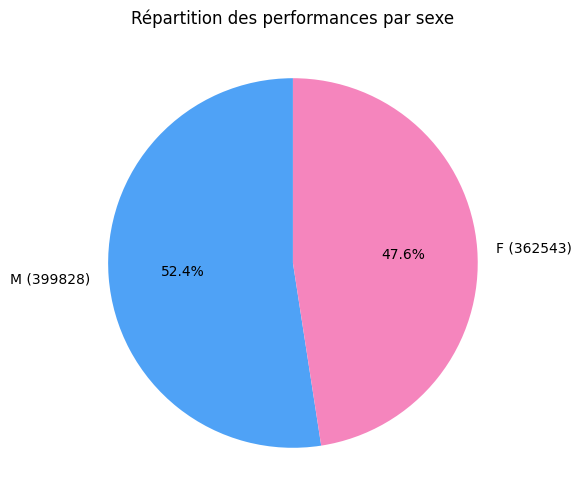

In [31]:
gender_counts = df["Gender"].value_counts()

colors = ["#4FA2F6","#F585BD"]

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Répartition des performances par sexe")

plt.show()

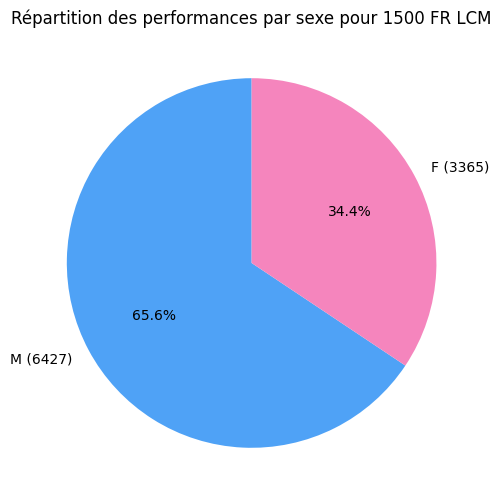

In [33]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event].copy()

df_event["Gender"] = df_event["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

gender_counts = df_event["Gender"].value_counts()

if len(gender_counts) > 0:
    colors = ["#4FA2F6", "#F585BD"]

    plt.figure(figsize=(6,6))

    plt.pie(
        gender_counts,
        labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )

    plt.title(f"Répartition des performances par sexe pour {nom_event}")
    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [34]:
print(df['Stroke'].unique()) # ['FR', 'BK', 'BR', 'FL', 'MD']

['FR' 'BK' 'BR' 'FL' 'MD']


<h1 style="color:#F0B4B4; font-size:32px;">Barplot (Diagramme a barres) du temps moyen par stroke et la distance</h1>

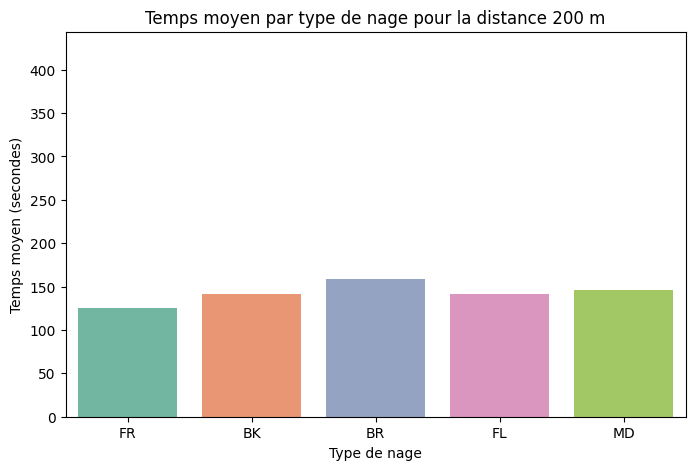

In [35]:
distance_choisie = 200

subset = df[
    (df['SwimTimeSeconds'].notna()) &
    (df['Distance'] == distance_choisie)
]

if len(subset) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Stroke',
        y='SwimTimeSeconds',
        data=subset,
        hue='Stroke',
        palette="Set2",
        errorbar=None,
        dodge=False
    )

    plt.title(f"Temps moyen par type de nage pour la distance {distance_choisie} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps moyen (secondes)")
    plt.ylim(0, subset['SwimTimeSeconds'].max() + 5)

    plt.show()
else:
    print(f"Aucune donnée disponible pour la distance {distance_choisie} m")

<h1 style="color:#F0B4B4; font-size:32px;">Bar Chart: Number of Performances per Club</h1>

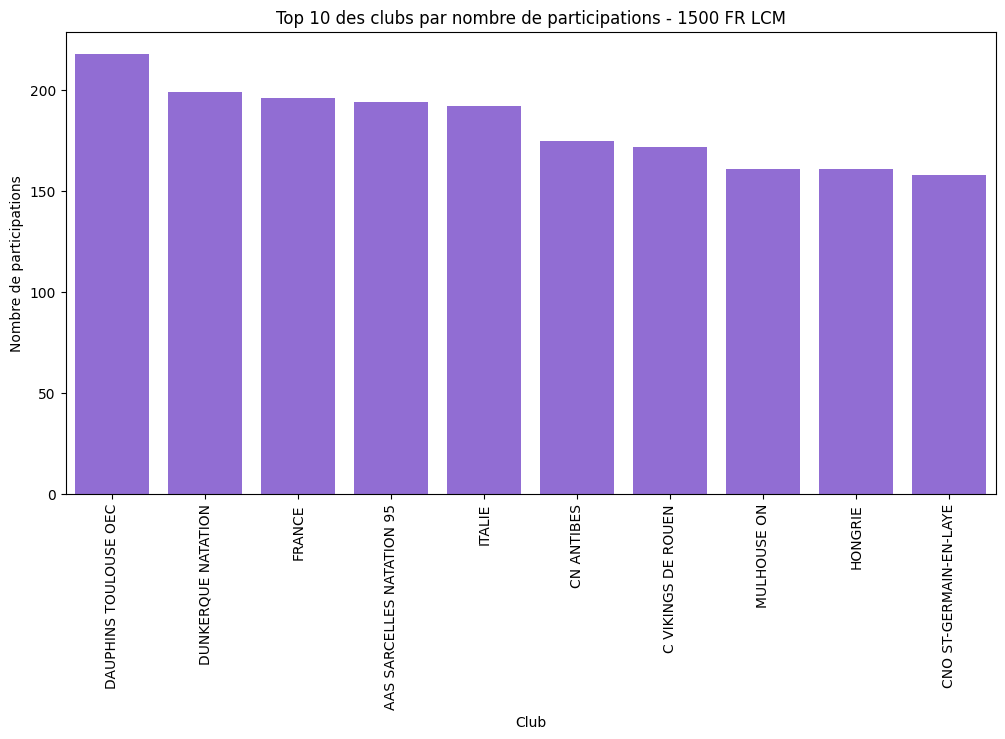

In [36]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event]

top_clubs = df_event["Club"].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#8C5CE4")

plt.title(f"Top 10 des clubs par nombre de participations - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Nombre de participations")
plt.xticks(rotation=90)

plt.show()

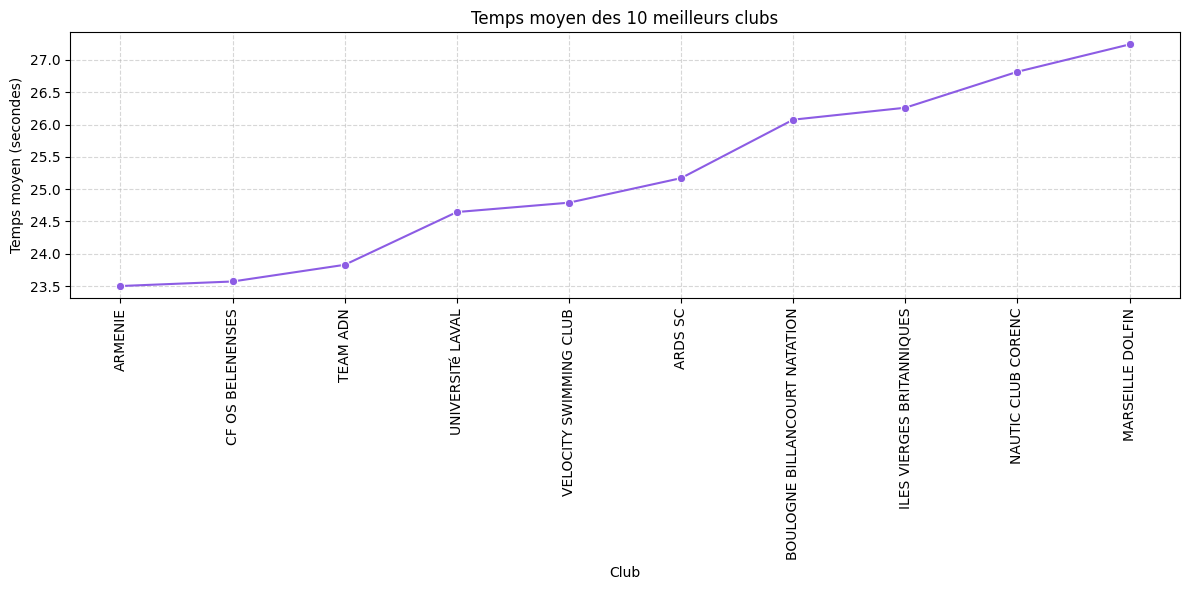

In [21]:
df_time = df[df['SwimTimeSeconds'].notna()]

mean_time_club = df_time.groupby('Club')['SwimTimeSeconds'].mean().reset_index()

mean_time_club = mean_time_club.sort_values('SwimTimeSeconds')

top10_clubs = mean_time_club.head(10)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=top10_clubs,
    x='Club',
    y='SwimTimeSeconds',
    marker='o',
    color="#8C5CE4"
)

plt.title("Temps moyen des 10 meilleurs clubs")
plt.xlabel("Club")
plt.ylabel("Temps moyen (secondes)")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000</h1>

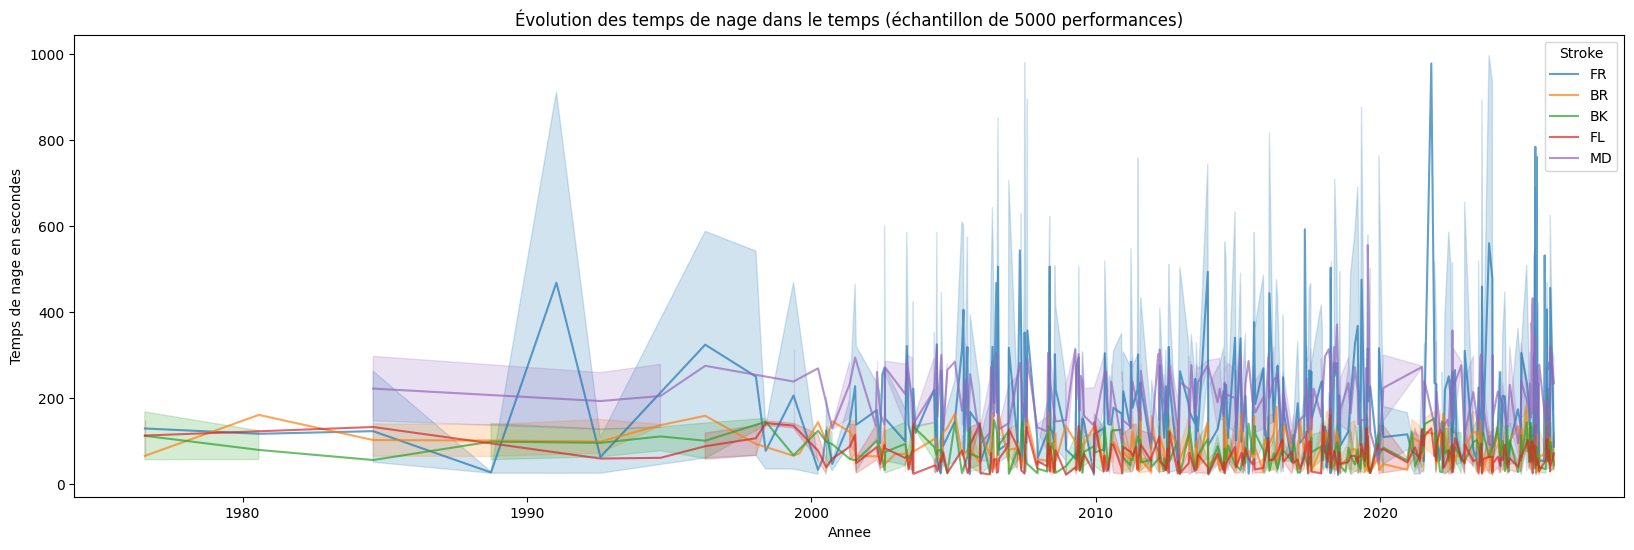

In [39]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'])
plt.figure(figsize=(20,6))
sns.lineplot(x='SwimDate', y='SwimTimeSeconds', data=df.sample(5000), hue='Stroke', alpha=0.7)
plt.title("Évolution des temps de nage dans le temps (échantillon de 5000 performances)")
plt.xlabel("Annee")
plt.ylabel("Temps de nage en secondes")
plt.legend(title='Stroke')
plt.show()

In [40]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'], errors='coerce')

df['Year'] = df['SwimDate'].dt.year

min_year = df['Year'].min()

print("L'année la plus ancienne est :", min_year)

L'année la plus ancienne est : 1976


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_3393/1076660305.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


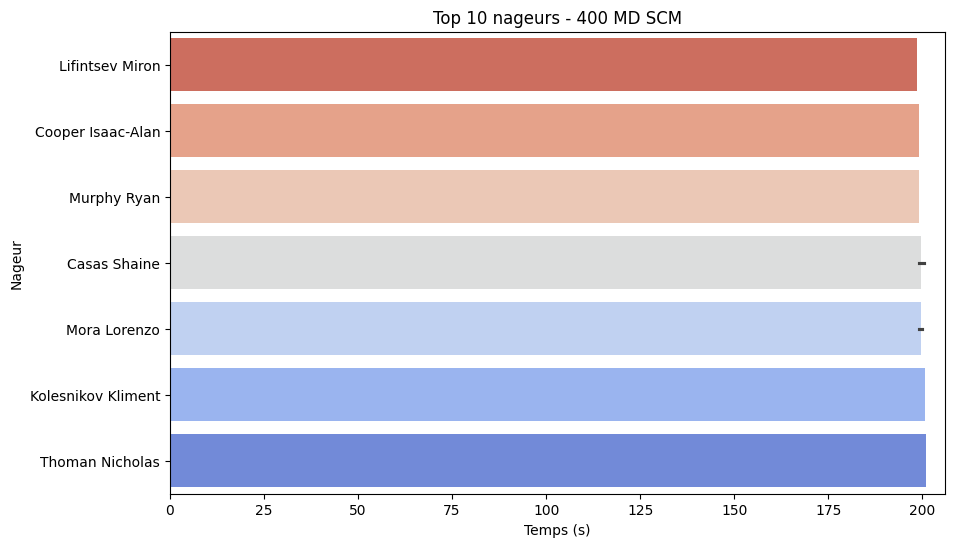

In [51]:
nom_event = "400 MD SCM"

subset = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['SwimTimeSeconds'] > 0)
].copy()

if len(subset) > 0:
    subset['SwimmerName'] = subset['swimmer'].apply(
        lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else "Unknown"
    )

    top10 = subset.nsmallest(10, 'SwimTimeSeconds')

    plt.figure(figsize=(10,6))
    sns.barplot(
        x='SwimTimeSeconds',
        y='SwimmerName',
        data=top10,
        palette="coolwarm_r",
        orient='h'
    )

    plt.title(f"Top 10 nageurs - {nom_event}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Nageur")
    plt.xlim(0, top10['SwimTimeSeconds'].max() + 5)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [49]:
print(df["Distance"].sort_values(ascending=True).unique()) # [  25   50  100  200  400  500  800 1000 1200 1500]

[  25   50  100  200  400  500  800 1000 1200 1500]


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed Performance Across Distances by Stroke</h1>

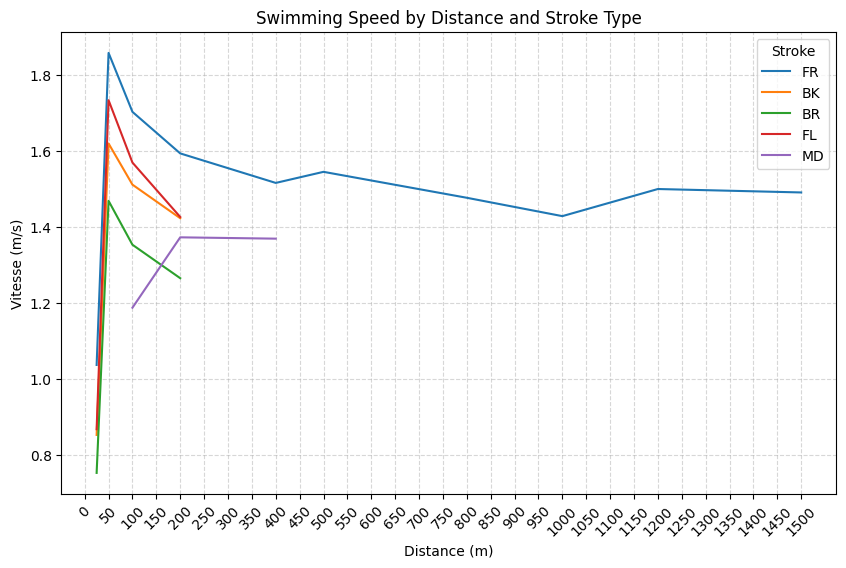

In [55]:
df_speed = df[df['Speed'].notna()]

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=df_speed,
    errorbar=None
)

max_distance = int(df_speed['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50), rotation=45)

plt.title("Swimming Speed by Distance and Stroke Type")
plt.xlabel("Distance (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


Top 10 swimmers for stroke: BK


,Swimmer,SwimTimeSeconds,Distance,Speed
222264,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",22.22,50,2.2502
35461,"{'Name': 'Lifintsev Miron', 'Gender': 'M', 'Ye...",22.47,50,2.2252
35462,"{'Name': 'Cooper Isaac', 'Gender': 'M', 'Year_...",22.49,50,2.2232
24529,"{'Name': 'Cooper Isaac-Alan', 'Gender': 'M', '...",22.52,50,2.2202
35463,"{'Name': 'Ryan Shane', 'Gender': 'M', 'Year_of...",22.56,50,2.2163
...,...,...,...,...
88665,"{'Name': 'Murphy Ryan', 'Gender': 'M', 'Year_o...",114.52,200,1.7464
88673,"{'Name': 'Murphy Ryan', 'Gender': 'M', 'Year_o...",115.43,200,1.7327
90567,"{'Name': 'Rylov Evgeny', 'Gender': 'M', 'Year_...",115.50,200,1.7316
90575,"{'Name': 'Rylov Evgeny', 'Gender': 'M', 'Year_...",116.67,200,1.7142



Top 10 swimmers for stroke: BR


,Swimmer,SwimTimeSeconds,Distance,Speed
24680,"{'Name': 'Fink Nic', 'Gender': 'M', 'Year_of_b...",25.38,50,1.9701
65169,"{'Name': 'Van Der Burgh Cameron', 'Gender': 'M...",25.41,50,1.9677
35661,"{'Name': 'Qin Haiyang', 'Gender': 'M', 'Year_o...",25.42,50,1.9670
24681,"{'Name': 'Martinenghi Nicolni', 'Gender': 'M',...",25.42,50,1.9670
35669,"{'Name': 'Prigoda Kirill', 'Gender': 'M', 'Yea...",25.48,50,1.9623
...,...,...,...,...
226046,"{'Name': 'Shymanovich Ilya', 'Gender': 'M', 'Y...",124.99,200,1.6001
88888,"{'Name': 'Fink Nic', 'Gender': 'M', 'Year_of_b...",129.05,200,1.5498
88898,"{'Name': 'Fink Nic', 'Gender': 'M', 'Year_of_b...",129.23,200,1.5476
88915,"{'Name': 'Fink Nic', 'Gender': 'M', 'Year_of_b...",130.27,200,1.5353



Top 10 swimmers for stroke: FL


,Swimmer,SwimTimeSeconds,Distance,Speed
35901,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.32,50,2.3452
35909,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.43,50,2.3332
18266,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",21.51,50,2.3245
35925,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.53,50,2.3223
18258,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",21.54,50,2.3213
...,...,...,...,...
18412,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",110.17,200,1.8154
18420,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",111.53,200,1.7932
73970,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",111.79,200,1.7891
18440,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",112.34,200,1.7803



Top 10 swimmers for stroke: FR


,Swimmer,SwimTimeSeconds,Distance,Speed
35021,"{'Name': 'Crooks Jordan', 'Gender': 'M', 'Year...",19.90,50,2.5126
35037,"{'Name': 'Crooks Jordan', 'Gender': 'M', 'Year...",20.08,50,2.4900
73183,"{'Name': 'Proud Benjamin', 'Gender': 'M', 'Yea...",20.18,50,2.4777
35013,"{'Name': 'Crooks Jordan', 'Gender': 'M', 'Year...",20.19,50,2.4765
11927,"{'Name': 'Bernard Alain', 'Gender': 'M', 'Year...",80.77,200,2.4762
...,...,...,...,...
517365,"{'Name': 'Leveaux Amaury', 'Gender': 'M', 'Yea...",106.54,200,1.8772
517381,"{'Name': 'Leveaux Amaury', 'Gender': 'M', 'Yea...",107.10,200,1.8674
517389,"{'Name': 'Leveaux Amaury', 'Gender': 'M', 'Yea...",107.36,200,1.8629
86272,"{'Name': 'Leveaux Amaury', 'Gender': 'M', 'Yea...",228.99,400,1.7468



Top 10 swimmers for stroke: MD


,Swimmer,SwimTimeSeconds,Distance,Speed
25286,"{'Name': 'Mora Lorenzo', 'Gender': 'M', 'Year_...",89.72,200,2.2292
25287,"{'Name': 'Murphy Ryan', 'Gender': 'M', 'Year_o...",90.37,200,2.2131
38731,"{'Name': 'Kolesnikov Kliment', 'Gender': 'M', ...",90.44,200,2.2114
18671,"{'Name': 'Lazzari Francesco', 'Gender': 'M', '...",90.49,200,2.2102
226532,"{'Name': 'Casas Shaine', 'Gender': 'M', 'Year_...",90.51,200,2.2097
223521,"{'Name': 'Guido Guilherme', 'Gender': 'M', 'Ye...",90.51,200,2.2097
226531,"{'Name': 'Kolesnikov Kliment', 'Gender': 'M', ...",90.51,200,2.2097
76296,"{'Name': 'Kolesnikov Kliment', 'Gender': 'M', ...",90.63,200,2.2068
226533,"{'Name': 'Mora Lorenzo', 'Gender': 'M', 'Year_...",90.78,200,2.2031
74150,"{'Name': 'Mora Lorenzo', 'Gender': 'M', 'Year_...",90.78,200,2.2031


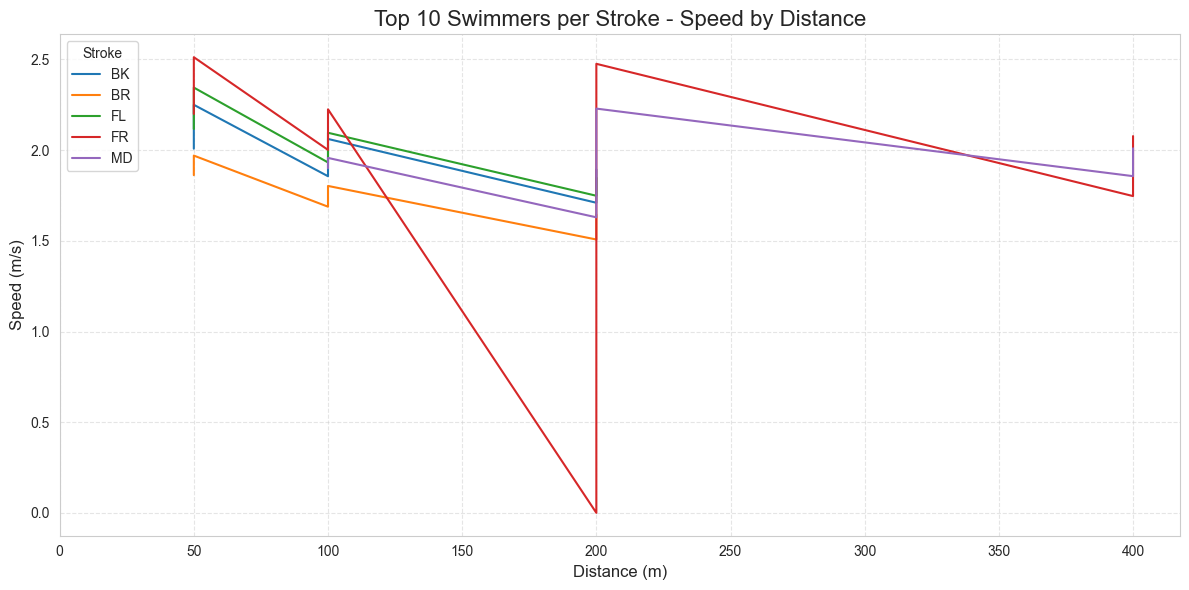

In [57]:
import mplcursors
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# On nettoie les valeurs manquantes
df_clean = df[df['Speed'].notna()]

# Fonction pour extraire le nom du nageur
def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name', str(x))
    elif isinstance(x, list) and len(x) > 0:
        return str(x[0])
    else:
        return str(x)

df_clean['Swimmer'] = df_clean['swimmer'].apply(clean_swimmer)

# Trier par stroke, nageur et distance
df_clean = df_clean.sort_values(by=['Stroke', 'Swimmer', 'Distance'])

# Sélection des top 10 nageurs par stroke sur **leur meilleure performance**
top_swimmers = pd.DataFrame()
for stroke in df_clean['Stroke'].unique():
    df_s = df_clean[df_clean['Stroke'] == stroke].sort_values('Speed', ascending=False)
    top10_swimmers = df_s['Swimmer'].drop_duplicates().head(10)  # 10 premiers nageurs
    top_swimmers = pd.concat([top_swimmers, df_s[df_s['Swimmer'].isin(top10_swimmers)]])

# Affichage
for stroke in top_swimmers['Stroke'].unique():
    print(f"\nTop 10 swimmers for stroke: {stroke}")
    display(top_swimmers[top_swimmers['Stroke'] == stroke][['Swimmer','SwimTimeSeconds','Distance','Speed']])

# Graphique
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=top_swimmers,
    markers=True,
    dashes=False,
    estimator=None
)

max_distance = int(top_swimmers['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50))  # pas de 50 m

# Pour mplcursors
points = list(zip(top_swimmers['Distance'], top_swimmers['Speed'], top_swimmers['Swimmer']))
cursor = mplcursors.cursor(ax.lines, hover=True)

@cursor.connect("add")
def on_add(sel):
    x_data, y_data = sel.target
    nearest = min(points, key=lambda p: (p[0]-x_data)**2 + (p[1]-y_data)**2)
    sel.annotation.set_text(f"{nearest[2]}\nSpeed: {nearest[1]:.2f} m/s\nDistance: {nearest[0]} m")

plt.title("Top 10 Swimmers per Stroke - Speed by Distance", fontsize=16)
plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Speed (m/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Heatmap of Average Swim Speed by Distance and Stroke</h1>

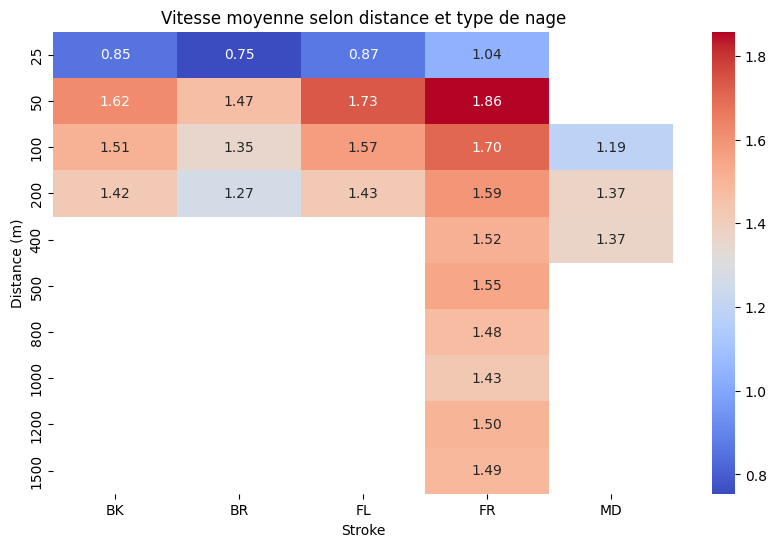

In [5]:
pivot = df.pivot_table(
    values='Speed',
    index='Distance',
    columns='Stroke',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Vitesse moyenne selon distance et type de nage")
plt.xlabel("Stroke")
plt.ylabel("Distance (m)")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed ​​per split for a precise Swimmer and Event</h1>

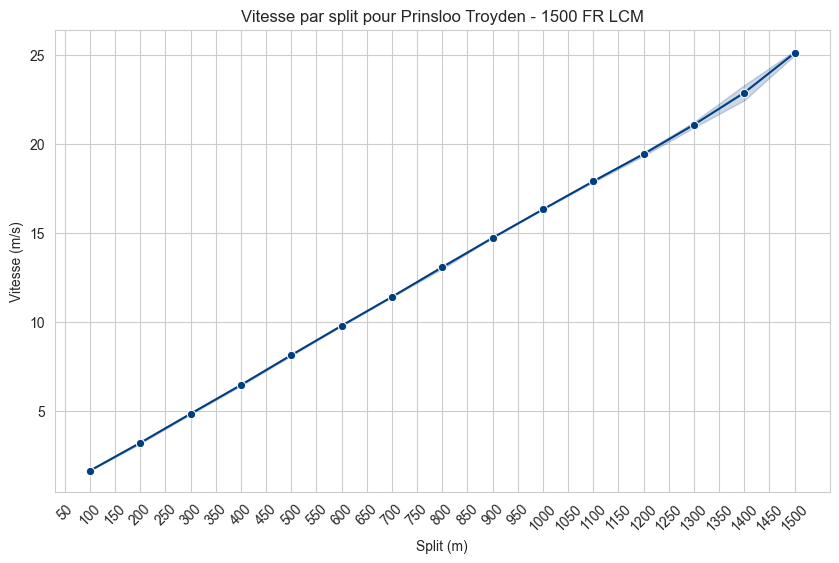

In [29]:
nom_nageur = "Prinsloo Troyden"
nom_event = "1500 FR LCM"

split_data = []
gender_nageur = None  

for idx, row in df.iterrows():
    if row['Event'] == nom_event and len(row['swimmer']) == 1:
        swimmer = row['swimmer'][0]
        if swimmer['Name'] == nom_nageur:
            gender_nageur = swimmer['Gender']  
            for s in row['splits']:
                if s['split_speed'] is not None:
                    dist = int(s['split_distance'].replace(' m',''))
                    split_data.append({
                        'split_distance': dist,
                        'split_speed': s['split_speed']
                    })

df_splits = pd.DataFrame(split_data)

df_splits = df_splits.sort_values('split_distance')

if gender_nageur == "M":
    color_line = "#003E80"  
elif gender_nageur == "F":
    color_line = "#FF69B4"  
else:
    color_line = "#008080"  

plt.figure(figsize=(10,6))
sns.lineplot(
    x='split_distance',
    y='split_speed',
    data=df_splits,
    marker='o',
    color=color_line
)
plt.xticks(range(50, df_splits['split_distance'].max()+50, 50), rotation = 45) 
plt.title(f"Vitesse par split pour {nom_nageur} - {nom_event}")
plt.xlabel("Split (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event</h1>

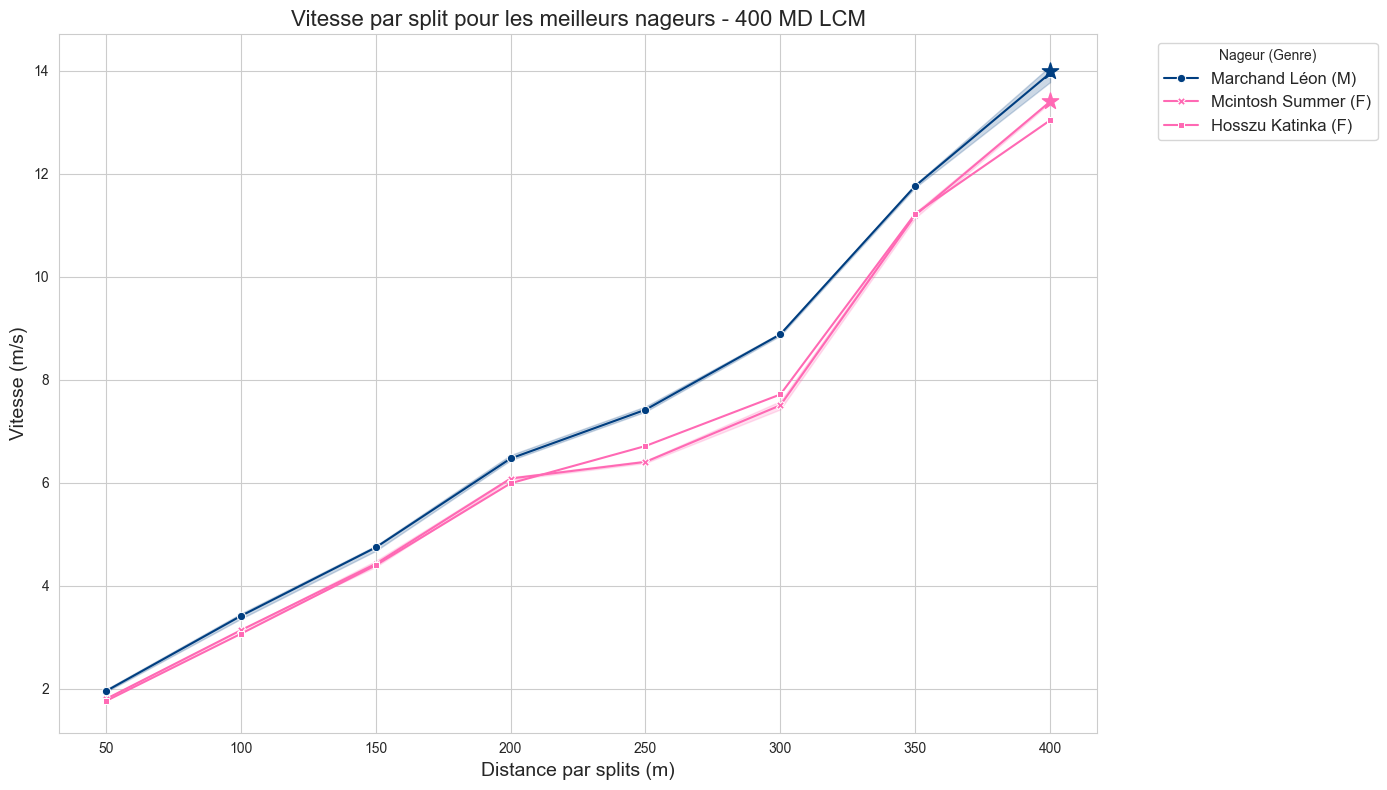

In [30]:
nom_event = "400 MD LCM"
top_n = 3  

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    best_male = df_top_men.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]
    best_female = df_top_women.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]

    for swimmer in [best_male, best_female]:
        swimmer_data = df_splits[df_splits['swimmer'] == swimmer]
        color = palette_for_plot[swimmer + f" ({swimmer_data['gender'].iloc[0]})"]

        plt.scatter(
            swimmer_data['split_distance'].iloc[-1],
            swimmer_data['split_speed'].iloc[-1],
            s=150,  
            color=color,
            marker='*',
            zorder=5
        )

    plt.tight_layout()
    plt.show()

In [31]:
df_event = df[
    (df['Event'] == "1500 FR LCM") &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1) &
     df['splits'].apply(lambda x: isinstance(x, list) and len(x) == 15))
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

swimmers_in_event = df_event[['swimmer_name', 'swimmer_gender']].drop_duplicates()

print(len(swimmers_in_event))
# y a des nageurs qui n ont pas tous les splits

947


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event (women vs men)</h1>

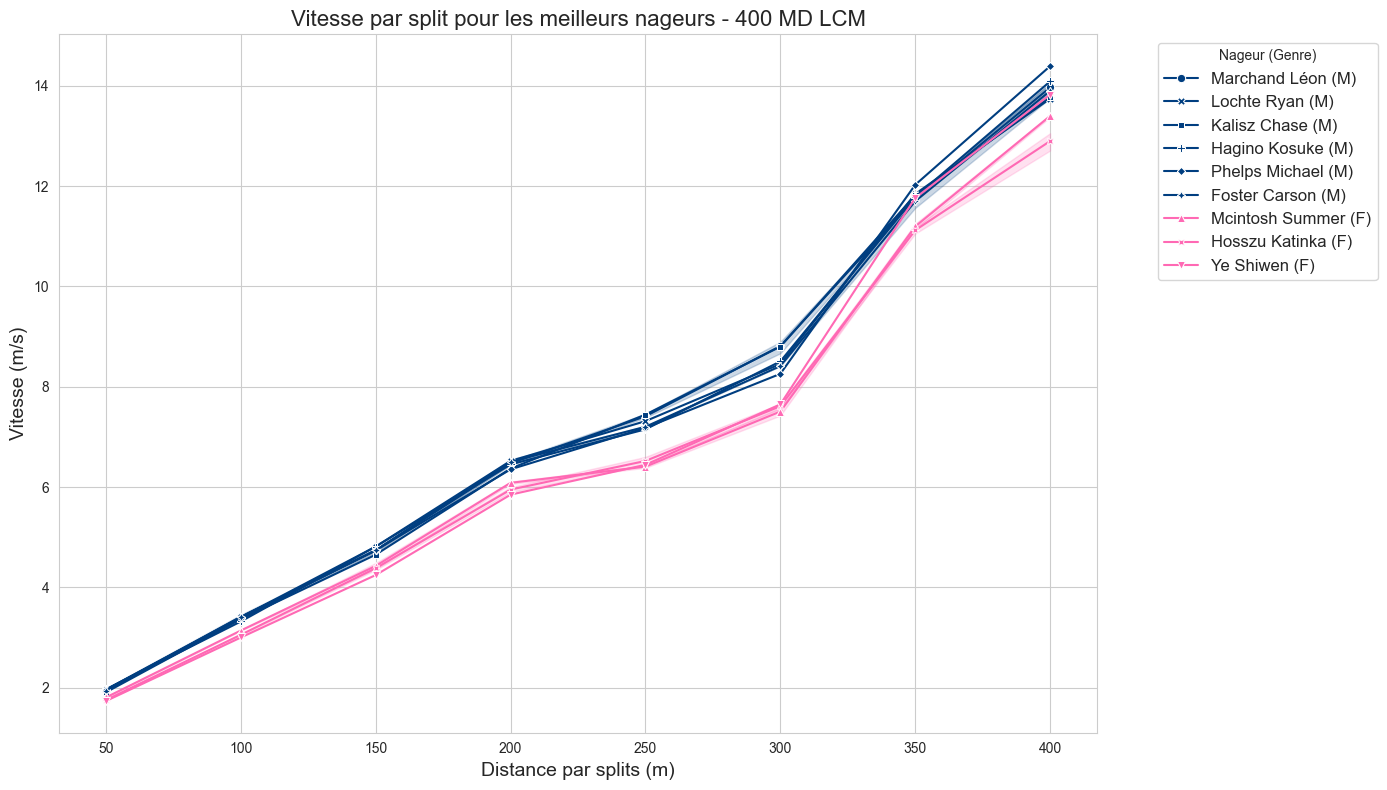

In [32]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits: 
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmer in a given event</h1>

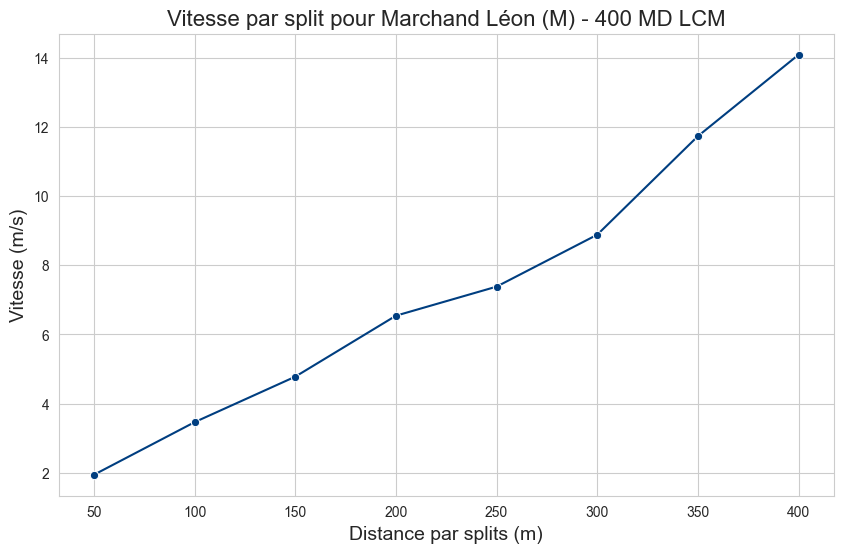

In [33]:
nom_event = "400 MD LCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]

best_name = df_best['swimmer_name']
best_gender = df_best['swimmer_gender']
best_splits = df_best['splits']

split_data = []
for s in best_splits:
    if s['split_speed'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_data.append({
            'split_distance': dist,
            'split_speed': s['split_speed']
        })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print(f"Aucun split valide trouvé pour le meilleur nageur de l'Event {nom_event}.")
else:
    plt.figure(figsize=(10,6))
    color = "#003E80" if best_gender == 'M' else "#FF69B4"

    sns.lineplot(
        x='split_distance',
        y='split_speed',
        data=df_splits,
        marker='o',
        color=color
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour {best_name} ({best_gender}) - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of average of swim time by splits</h1>

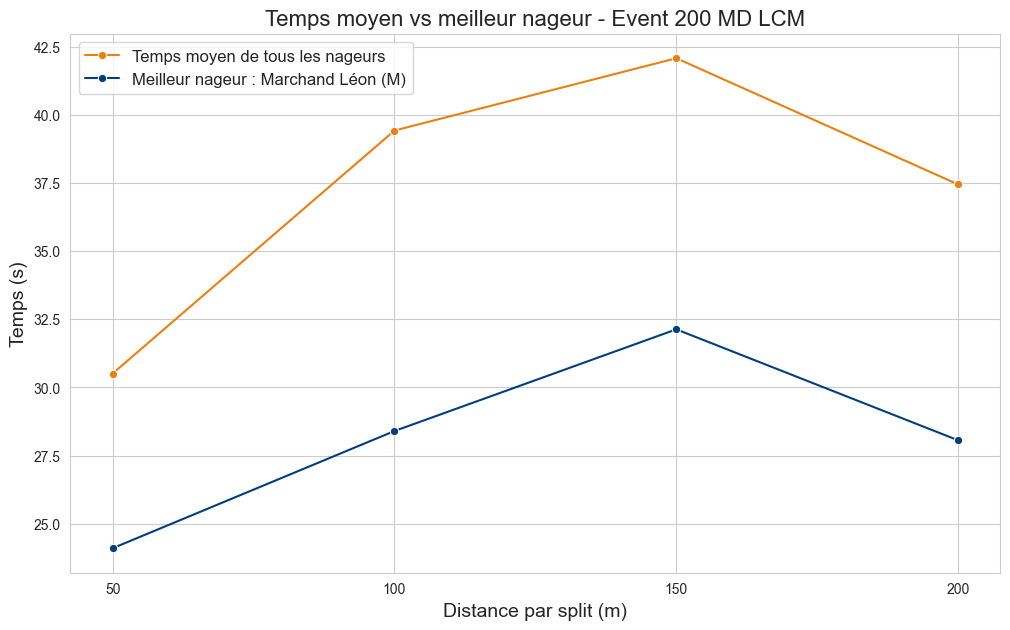

In [34]:
nom_event = "200 MD LCM"  
df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]
best_name = df_best['swimmer'][0]['Name']
best_gender = df_best['swimmer'][0]['Gender']
best_splits = df_best['splits']

split_best_data = []
for s in best_splits:
    if s['split_seconds'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_best_data.append({
            'split_distance': dist,
            'split_seconds': s['split_seconds']
        })

df_best_splits = pd.DataFrame(split_best_data)

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

color_best = "#003E80" if best_gender == 'M' else "#FF69B4"
sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_best_splits,
    marker='o',
    color=color_best,
    label=f"Meilleur nageur : {best_name} ({best_gender})"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(), df_best_splits['split_distance'].max())+50, 50))
plt.title(f"Temps moyen vs meilleur nageur - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

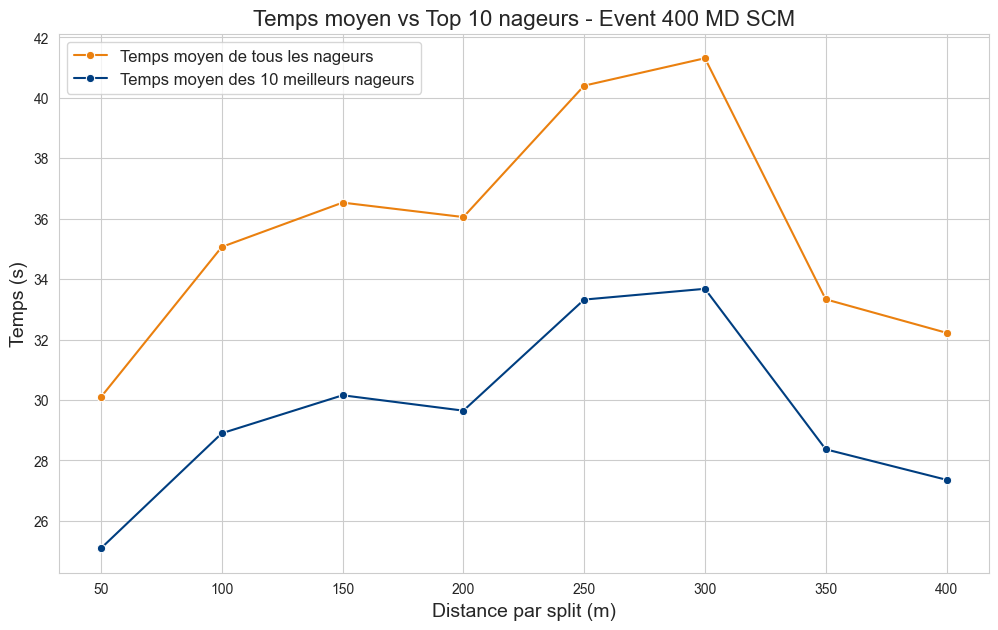

In [35]:
nom_event = "400 MD SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_top10 = df_event.nsmallest(10, 'SwimTimeSeconds')

top10_split_data = []

for idx, row in df_top10.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                top10_split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_top10_splits = pd.DataFrame(top10_split_data)

df_top10_mean = df_top10_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_top10_mean,
    marker='o',
    color="#003E80",
    label="Temps moyen des 10 meilleurs nageurs"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(),
                         df_top10_mean['split_distance'].max()) + 50, 50))

plt.title(f"Temps moyen vs Top 10 nageurs - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

plt.show()

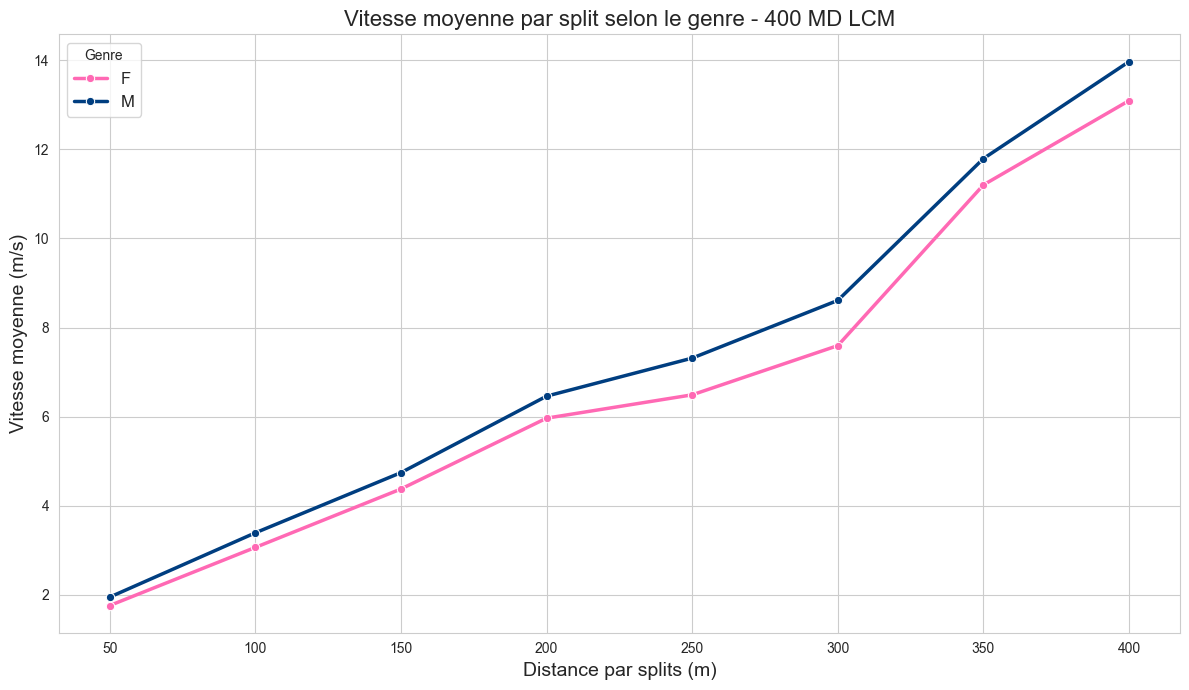

In [36]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            dist = int(s['split_distance'].replace(' m',''))
            split_speed = s['split_speed'] if s['split_speed'] is not None else float('nan')
            split_data.append({
                'gender': gender,
                'split_distance': dist,
                'split_speed': split_speed
            })

df_splits = pd.DataFrame(split_data)

df_avg = df_splits.groupby(['gender', 'split_distance'])['split_speed'].mean().reset_index()

plt.figure(figsize=(12,7))
palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

sns.lineplot(
    x='split_distance',
    y='split_speed',
    hue='gender',
    data=df_avg,
    marker='o',
    palette=palette_colors,
    linewidth=2.5
)

plt.xticks(range(50, int(df_splits['split_distance'].max())+50, 50))
plt.title(f"Vitesse moyenne par split selon le genre - {nom_event}", fontsize=16)
plt.xlabel("Distance par splits (m)", fontsize=14)
plt.ylabel("Vitesse moyenne (m/s)", fontsize=14)
plt.grid(True)
plt.legend(title='Genre', fontsize=12)
plt.tight_layout()
plt.show()

In [47]:
print("Les event disponibles sont :")
print(df["Event"].unique()) 
print("Le nombre de event disponibles :",len(df["Event"].unique())) 

Les event disponibles sont :
['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']
Le nombre de event disponibles : 44


In [49]:
df_filtered = df[
    (df['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)) &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1))
]

events_filtered = df_filtered['Event'].unique()

print("Nombre d'événements uniques avec des splits valides pour un seul nageur (pas de relais) est :", len(events_filtered))

Nombre d'événements uniques avec des splits valides pour un seul nageur (pas de relais) est : 26


In [50]:
nom_event = "50 FL LCM"

df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

df_filtered = df[df['swimmer_name'].notna()]

total_participations = (
    df_filtered[df_filtered['Event'] == nom_event]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='total_participations')
)

valid_performances = (
    df_filtered[(df_filtered['Event'] == nom_event) & df_filtered['SwimTimeSeconds'].notna()]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='valid_performances')
)

top_swimmers = pd.merge(total_participations, valid_performances, on='swimmer_name', how='left')

top_swimmers = top_swimmers.sort_values(by='total_participations', ascending=False).head(10)

top_swimmers['valid_performances'] = top_swimmers['valid_performances'].fillna(0).astype(int)
top_swimmers['total_participations'] = top_swimmers['total_participations'].astype(int)

top_swimmers = top_swimmers.rename(columns={
    'swimmer_name': 'Nom des nageurs',
    'total_participations': 'Total performances',
    'valid_performances': 'Total performances valides'
})

print("Les nageurs qui ont le nombre de performances le plus élevé pour le event", nom_event, " :")
print(top_swimmers)

Les nageurs qui ont le nombre de performances le plus élevé pour le event 50 FL LCM  :
          Nom des nageurs  Total performances  Total performances valides
5719      Henique Mélanie                 144                         143
12866        Wattel Marie                  82                          81
1652   Bousquet Frédérick                  76                          76
5333      Grousset Maxime                  72                          71
8481        Metella Mehdy                  69                          68
9917         Piron Thomas                  62                          62
434        Arlandis Anais                  61                          61
9569    Pedro-Leal Dorian                  60                          60
7957     Manaudou Florent                  60                          59
1862        Bruno Justine                  58                          58


In [42]:
df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

participations = df.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur ayant le nombre de performances le plus élevé est :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur ayant le nombre de performances le plus élevé est :
           swimmer_name      Event  count
129264  Henique Mélanie  50 FL LCM    144


In [21]:
df_exploded = df.explode('swimmer')

def extract_field(x, field):
    return x.get(field) if isinstance(x, dict) else None

df_exploded['Name'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Name'))
df_exploded['Year_of_birth'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Year_of_birth'))
df_exploded['Age'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Age'))
df_exploded['Gender'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Gender'))

df_exploded['SwimYear'] = pd.to_datetime(df_exploded['SwimDate']).dt.year

year_counts = (
    df_exploded
    .groupby('Name')['Year_of_birth']
    .nunique()
    .reset_index(name='nb_years')
)

multiple_years = year_counts[year_counts['nb_years'] > 1]['Name'].tolist()

print(f"Nombre de nageurs avec plusieurs Year_of_birth : {len(multiple_years)}")

pourcentage_nageurs = (
    len(multiple_years) / df_exploded['Name'].nunique()
) * 100

print(f"Pourcentage de nageurs concernés : {pourcentage_nageurs:.2f}%\n")


df_problematic = df_exploded[
    df_exploded['Name'].isin(multiple_years)
]


age_check = (
    df_problematic
    .groupby(['Name', 'SwimYear', 'Year_of_birth'])['Age']
    .nunique()
    .reset_index(name='nb_ages')
)

age_inconsistencies = age_check[age_check['nb_ages'] > 1]

print("Nageurs avec Age incohérent pour une même SwimYear et Year_of_birth :")
print(age_inconsistencies)


nb_nageurs_problematiques = df_problematic['Name'].nunique()

pourcentage_incoherences = (
    len(age_inconsistencies) / nb_nageurs_problematiques
) * 100 if nb_nageurs_problematiques > 0 else 0

print(f"\nPourcentage de nageurs avec incohérences d'Age : {pourcentage_incoherences:.2f}%")


gender_check = (
    df_exploded
    .groupby('Name')
    .agg({
        'Year_of_birth': 'nunique',
        'Gender': 'nunique'
    })
    .reset_index()
)

same_gender_multiple_yob = gender_check[
    (gender_check['Year_of_birth'] > 1) &
    (gender_check['Gender'] == 1)
]

print(f"\nNombre de nageurs avec plusieurs Year_of_birth et même Gender : {len(same_gender_multiple_yob)}")

Nombre de nageurs avec plusieurs Year_of_birth : 312
Pourcentage de nageurs concernés : 0.46%

Nageurs avec Age incohérent pour une même SwimYear et Year_of_birth :
                  Name  SwimYear  Year_of_birth  nb_ages
15        Angot Julien      2009           1992        2
16        Angot Julien      2010           1992        2
52     Bernard Camille      2017           2002        2
54     Bernard Camille      2019           2002        2
86     Boudet Clémence      2011           1995        2
...                ...       ...            ...      ...
1163     Seebohm Emily      2016           1992        2
1192      Smith Daniel      2016           1991        2
1215    Thomas Mathieu      2005           1984        2
1253  Wagner Alexandre      2005           1988        2
1275            Yu Rui      2004           1982        2

[144 rows x 4 columns]

Pourcentage de nageurs avec incohérences d'Age : 46.15%

Nombre de nageurs avec plusieurs Year_of_birth et même Gender : 306


In [19]:
nom_nageur = "Angot Julien"
annee = 2005

df_nageur = df_exploded[
    (df_exploded['Name'] == nom_nageur) &
    (df_exploded['Year_of_birth'] == annee)
]

print("Nombre de performances du nageur :", len(df_nageur))

meet_nageur = df_nageur['Meet'].unique()

events_nageur = df_nageur['Event'].unique()

print(f"\n Meets pour {nom_nageur} ({annee}) :")
print(meet_nageur)

print(f"\n Events pour {nom_nageur} ({annee}) :")
print(events_nageur)

Nombre de performances du nageur : 2

 Meets pour Angot Julien (2005) :
['Interclubs Départementaux Toutes Catégories-LOIRE-ATLANTIQUE']

 Events pour Angot Julien (2005) :
['100 FL SCM' '500 FR SCM']


In [ ]:
swimmer_name_target = "Angot Julien"
swimmer_name_clean = swimmer_name_target.strip().lower()

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0]["Name"].strip().lower() if isinstance(x, list) and len(x) > 0 else None
)

df_swimmer = df[df["swimmer_name"] == swimmer_name_clean].copy()

distinct_years = df_swimmer["swimmer"].apply(
    lambda x: x[0].get("Year_of_birth") if isinstance(x, list) and len(x) > 0 else None
).dropna().unique()

print(f"Années de naissance distinctes pour {swimmer_name_target} :")
print(distinct_years)

Années de naissance distinctes pour Angot Julien :
[1992 2005]
[19 16 20 18 14 17 13 15]


In [24]:
total_lignes = len(df)

nb_null = df['SwimTimeSeconds'].isna().sum()
pourcentage_null = (nb_null / total_lignes) * 100

nb_empty = (df['SwimTimeSeconds'] == "").sum()
pourcentage_empty = (nb_empty / total_lignes) * 100

print(f"Nombre de SwimTimeSeconds nulles (NaN) : {nb_null} ({pourcentage_null:.2f}%)")
print(f"Nombre de SwimTimeSeconds vides ('') : {nb_empty} ({pourcentage_empty:.2f}%)")

Nombre de SwimTimeSeconds nulles (NaN) : 10596 (1.39%)
Nombre de SwimTimeSeconds vides ('') : 0 (0.00%)


<h1 style="color:#F0B4B4; font-size:32px;">Couloirs de performance (nageur + événement)</h1>

<p>Courbes en pointillés bleus&nbsp;: percentiles des <strong>rangs</strong> à chaque âge pour les <strong>top N</strong> nageurs du même sexe (meilleur temps carrière sur l’événement). <strong>Rang 1</strong> = meilleur temps à cet âge dans toute la base chargée. Axe Y inversé (le haut = mieux). Le nageur choisi est en trait plein.</p>


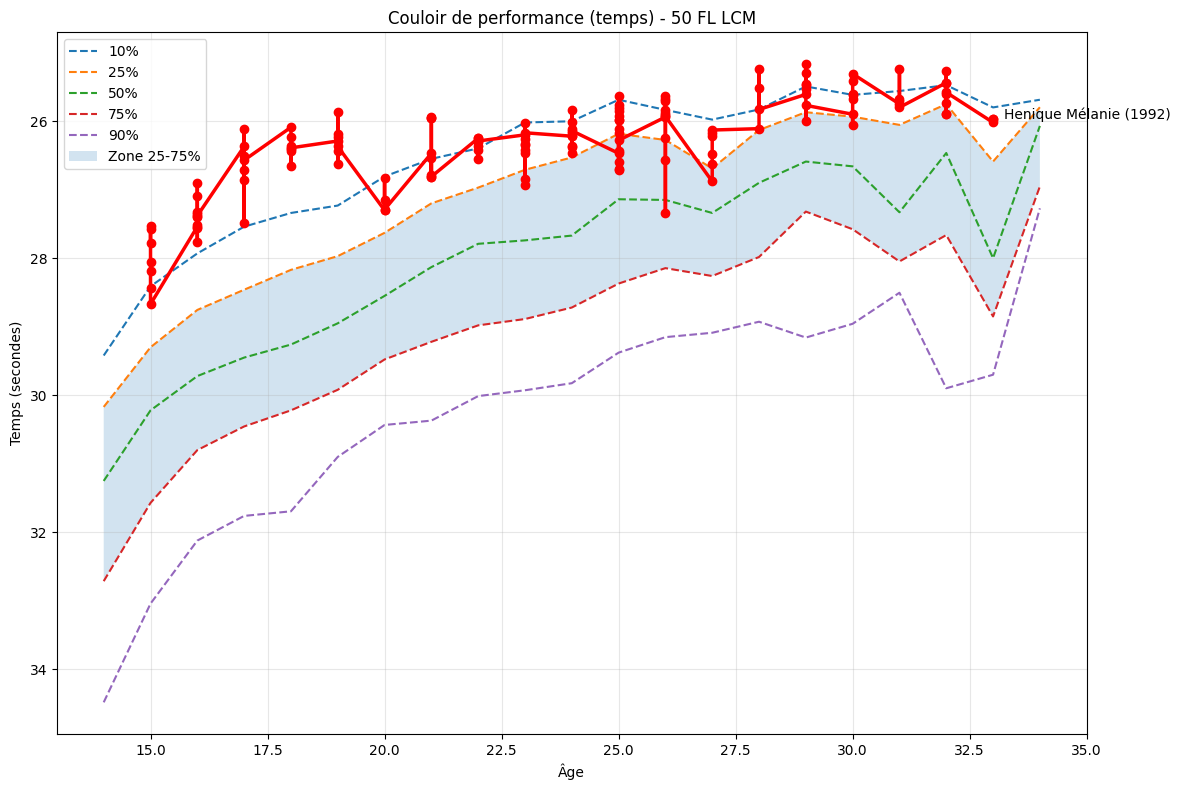

In [6]:
def build_long_swims(df, solo_only=True):
    """Une ligne par nageur-performance, avec âge calculé."""
    
    d = df.copy()

    if solo_only:
        d = d[d["swimmer"].apply(lambda x: isinstance(x, list) and len(x) == 1)]

    d = d.explode("swimmer")

    def ef(x, field):
        return x.get(field) if isinstance(x, dict) else None

    d["Name"] = d["swimmer"].apply(lambda x: ef(x, "Name"))
    d["Gender"] = d["swimmer"].apply(lambda x: ef(x, "Gender"))
    d["Year_of_birth"] = d["swimmer"].apply(lambda x: ef(x, "Year_of_birth"))
    d["Age_json"] = d["swimmer"].apply(lambda x: ef(x, "Age"))

    d["SwimYear"] = pd.to_datetime(d["SwimDate"], errors="coerce").dt.year

    d["Age_swim"] = d["Age_json"]

    mask = d["Age_swim"].isna() & d["Year_of_birth"].notna() & d["SwimYear"].notna()

    d.loc[mask, "Age_swim"] = (
        d.loc[mask, "SwimYear"] - d.loc[mask, "Year_of_birth"]
    )

    d["Age_swim"] = pd.to_numeric(d["Age_swim"], errors="coerce").round().astype("Int64")

    return d

def performance_corridor_plot_time(
    df,
    nom_event,
    nom_nageur,
    year_of_birth,
    age_min=14,
    age_max=35,
    solo_only=True,
    min_points=5,
    figsize=(12, 8),
):

    long_df = build_long_swims(df, solo_only=solo_only)

    long_df = long_df[
        (long_df["Event"] == nom_event)
        & long_df["SwimTimeSeconds"].notna()
        & long_df["Name"].notna()
        & long_df["Gender"].notna()
        & long_df["Age_swim"].notna()
        & long_df["Year_of_birth"].notna()
    ].copy()

    if long_df.empty:
        print(f"Aucune donnée pour {nom_event}")
        return

    target_name = nom_nageur.strip().lower()

    cand = long_df[
        (long_df["Name"].str.strip().str.lower() == target_name)
        & (long_df["Year_of_birth"] == year_of_birth)
    ]

    if cand.empty:
        print(f"Nageur introuvable : {nom_nageur} ({year_of_birth})")
        print("Exemples :", long_df["Name"].drop_duplicates().head(10).tolist())
        return

    gender = cand["Gender"].mode().iloc[0]
    long_df = long_df[long_df["Gender"] == gender]

    focal_name = cand.iloc[0]["Name"]
    focal_yob = cand.iloc[0]["Year_of_birth"]


    perc_levels = [10, 25, 50, 75, 90]

    df_percentiles = (
        long_df.groupby("Age_swim")["SwimTimeSeconds"]
        .agg(list)
        .apply(lambda x: x if len(x) >= min_points else np.nan)
        .dropna()
    )

    df_percentiles = pd.DataFrame({
        f"p{p}": df_percentiles.apply(lambda x: np.percentile(x, p))
        for p in perc_levels
    })

    df_percentiles = df_percentiles.loc[
        (df_percentiles.index >= age_min) &
        (df_percentiles.index <= age_max)
    ]

    df_swimmer = long_df[
        (long_df["Name"] == focal_name) &
        (long_df["Year_of_birth"] == focal_yob)
    ].sort_values("Age_swim")

    fig, ax = plt.subplots(figsize=figsize)

    for p in perc_levels:
        ax.plot(
            df_percentiles.index,
            df_percentiles[f"p{p}"],
            linestyle="--",
            label=f"{p}%"
        )

    ax.fill_between(
        df_percentiles.index,
        df_percentiles["p25"],
        df_percentiles["p75"],
        alpha=0.2,
        label="Zone 25-75%"
    )

    ax.plot(
        df_swimmer["Age_swim"],
        df_swimmer["SwimTimeSeconds"],
        color="red",
        linewidth=2.5,
        marker="o"
    )

    if not df_swimmer.empty:
        last = df_swimmer.iloc[-1]
        label_name = f"{focal_name} ({focal_yob})"
        ax.scatter(last["Age_swim"], last["SwimTimeSeconds"], color="red")
        ax.annotate(
            label_name,
            (last["Age_swim"], last["SwimTimeSeconds"]),
            xytext=(8, 0),
            textcoords="offset points"
        )

    ax.invert_yaxis()  # important en natation
    ax.set_xlabel("Âge")
    ax.set_ylabel("Temps (secondes)")
    ax.set_title(f"Couloir de performance (temps) - {nom_event}")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    return fig, ax

nom_event = "50 FL LCM"
nom_nageur = "Henique Mélanie"
year_of_birth = 1992

performance_corridor_plot_time(
    df,
    nom_event=nom_event,
    nom_nageur=nom_nageur,
    year_of_birth=year_of_birth,
    age_min=14,
    age_max=35
)

plt.show()